In [121]:
from matplotlib import pyplot as plt
import lime
import pandas as pd
import pickle
from utils import DataProcessor

In [122]:
data = DataProcessor("../../hyper_wheat_ds_ch_norm_prep_mode=dai.csv").split_data()

with open('../../../Models/catboost.pkl', 'rb') as f:
        model = pickle.load(f)

In [123]:
russian_feature_names = []
for name in data.x.columns:
    if 'std_mean' in name:
        wave = name.split('_')[-1]
        russian_feature_names.append(f'Станд. отклонение коэф. ({wave} нм)')
    elif 'src_mean' in name:
        wave = name.split('_')[-1]
        russian_feature_names.append(f'Ср. значение сырого коэф. ({wave} нм)')
    elif 'minmax_mean' in name:
        wave = name.split('_')[-1]
        russian_feature_names.append(f'Ср. значение норм. коэф. ({wave} нм)')
    else:
        russian_feature_names.append(name)

In [145]:
import lime.lime_tabular
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=data.x_train.values,
    feature_names=russian_feature_names,  # ← передаем русские названия
    class_names=['0', '1'],
    discretize_continuous=False  # False = числа, True = интервалы
)

In [89]:
explainer = lime.lime_tabular.LimeTabularExplainer( training_data=data.x_train.values,
                                                    feature_names=data.x.columns,
                                                    class_names=['0', '1'],
                                                    discretize_continuous=False)

Выбираем номер объекта

In [127]:
object = 61

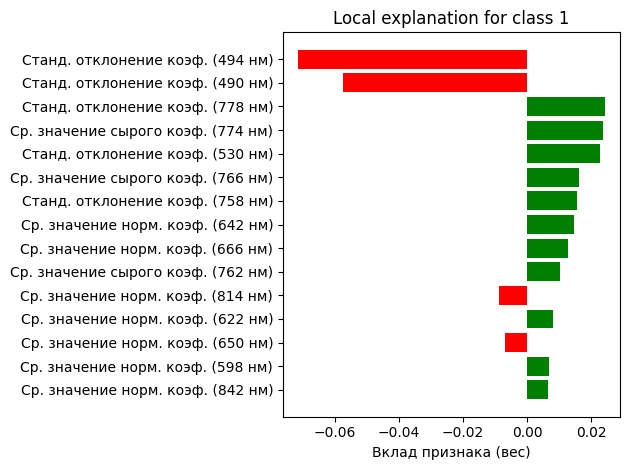

In [146]:
object = 0
exp = explainer.explain_instance(data.x_test.iloc[object].values, model.predict_proba, num_features=15)


exp.as_pyplot_figure()
plt.xlabel('Вклад признака (вес)')  # ← добавляем подпись оси X
plt.tight_layout()
plt.show()

In [82]:
feature_weights = pd.DataFrame(exp.as_list(), columns=['Признак', 'Вес признака'])
feature_values = data.x_test.iloc[object][feature_weights['Признак']].values
feature_weights['Значение признака'] = feature_values
print(feature_weights)

                  Признак  Вес признака  Значение признака
0      leafs_std_mean_494     -0.069486          -1.204013
1      leafs_std_mean_490     -0.064282          -1.321335
2      leafs_src_mean_490     -0.032153          -0.935024
3      leafs_std_mean_498     -0.024062          -0.972371
4      leafs_src_mean_766      0.020461           1.221170
5      leafs_std_mean_466     -0.019563          -0.820795
6      leafs_src_mean_486     -0.016890          -0.845664
7      leafs_src_mean_494     -0.016471          -0.967362
8      leafs_std_mean_482     -0.013377          -1.184348
9   leafs_minmax_mean_642      0.013092           0.034328
10     leafs_std_mean_734      0.013005           1.587263
11     leafs_std_mean_718      0.011409           1.769929
12  leafs_minmax_mean_846      0.010705           0.926739
13     leafs_src_mean_714     -0.009192           0.379577
14     leafs_std_mean_694      0.004908           1.858370


In [56]:
# Создаем словарь перевода {русское_название: английское_название}
translation_dict = {}
for eng_name in data.x.columns:
    if 'std_mean' in eng_name:
        wave = eng_name.split('_')[-1]
        rus_name = f'Станд. отклонение коэф. ({wave} нм)'
    elif 'src_mean' in eng_name:
        wave = eng_name.split('_')[-1]
        rus_name = f'Ср. значение сырого коэф. ({wave} нм)'
    elif 'minmax_mean' in eng_name:
        wave = eng_name.split('_')[-1]
        rus_name = f'Ср. значение норм. коэф. ({wave} нм)'
    else:
        rus_name = eng_name
    translation_dict[rus_name] = eng_name

# Получаем веса признаков от LIME
feature_weights = pd.DataFrame(exp.as_list(), columns=['Признак', 'Вес признака'])

# Получаем значения: для каждого русского названия берем соответствующее английское
feature_values = []
for rus_name in feature_weights['Признак']:
    eng_name = translation_dict[rus_name]
    value = data.x_test.iloc[object][eng_name]
    feature_values.append(value)

feature_weights['Значение признака'] = feature_values
print(feature_weights)

                               Признак  Вес признака  Значение признака
0     Станд. отклонение коэф. (494 нм)     -0.067155          -0.234332
1     Станд. отклонение коэф. (490 нм)     -0.060660          -0.157153
2     Станд. отклонение коэф. (778 нм)      0.023707           0.462719
3     Станд. отклонение коэф. (574 нм)      0.020189           0.162585
4     Станд. отклонение коэф. (586 нм)      0.019752           0.285235
5   Ср. значение сырого коэф. (766 нм)      0.019256           1.548084
6    Ср. значение норм. коэф. (666 нм)      0.019172           0.007052
7     Станд. отклонение коэф. (758 нм)      0.019083           0.131562
8   Ср. значение сырого коэф. (774 нм)      0.013470           1.579363
9     Станд. отклонение коэф. (766 нм)      0.013462           0.745726
10   Ср. значение норм. коэф. (642 нм)      0.012423           0.034813
11   Ср. значение норм. коэф. (814 нм)     -0.011129           0.924004
12   Ср. значение норм. коэф. (638 нм)     -0.007449           0

In [99]:
from IPython import display

display.HTML(exp.as_html(show_table=True))

In [137]:
explainer = lime.lime_tabular.LimeTabularExplainer(training_data=data.x_train.values,
                                                    feature_names=data.x.columns,
                                                    class_names=['0', '1'],
                                                    discretize_continuous=True)

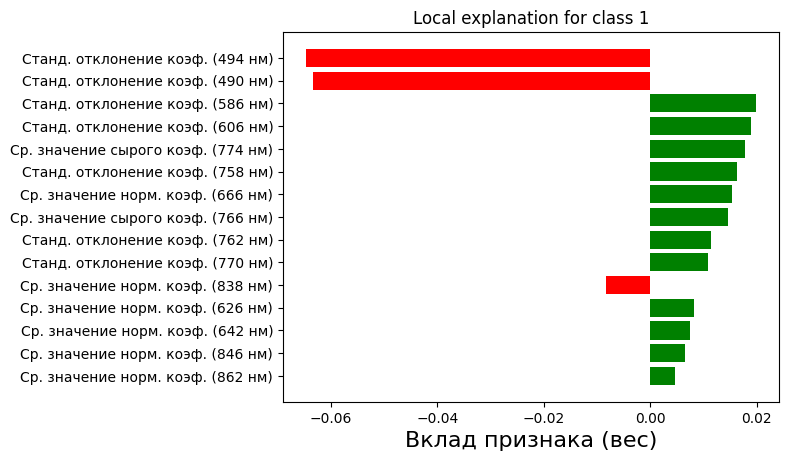

In [147]:
num_features = 15
exp = explainer.explain_instance(data.x_test.iloc[object].values, model.predict_proba, num_features=num_features)
exp.as_pyplot_figure()
plt.xlabel('Вклад признака (вес)', fontsize=16)
plt.show()

In [106]:
exp.save_to_file('lime_explanation.html')

In [37]:
df = pd.DataFrame(exp.as_list(), columns=['Границы признака', 'Вес признака'])
print(df)

                      Границы признака  Вес признака
0     Станд. отклонение коэф. (494 нм)     -0.066782
1     Станд. отклонение коэф. (490 нм)     -0.059318
2     Станд. отклонение коэф. (586 нм)      0.027278
3     Станд. отклонение коэф. (574 нм)      0.021941
4   Ср. значение сырого коэф. (774 нм)      0.017423
5     Станд. отклонение коэф. (758 нм)      0.017157
6   Ср. значение сырого коэф. (766 нм)      0.016934
7    Ср. значение норм. коэф. (666 нм)      0.014152
8   Ср. значение сырого коэф. (770 нм)      0.010730
9     Станд. отклонение коэф. (766 нм)      0.010002
10   Ср. значение норм. коэф. (642 нм)      0.009104
11   Ср. значение норм. коэф. (742 нм)     -0.008235
12  Ср. значение сырого коэф. (762 нм)      0.007433
13   Ср. значение норм. коэф. (650 нм)      0.006963
14   Ср. значение норм. коэф. (606 нм)      0.006321


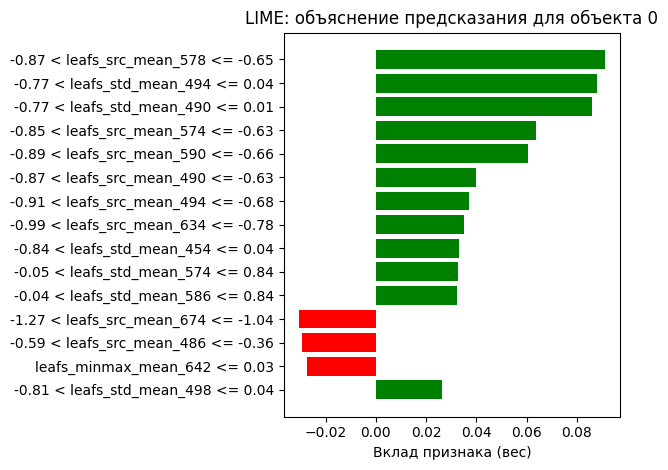

                                  Интервал признака  Значение признака  Вес признака
-0.87 < Ср. значение сырого коэф. (578 нм) <= -0.65          -0.832576      0.091166
   -0.77 < Станд. отклонение коэф. (494 нм) <= 0.04          -0.234332      0.087920
   -0.77 < Станд. отклонение коэф. (490 нм) <= 0.01          -0.157153      0.086017
-0.85 < Ср. значение сырого коэф. (574 нм) <= -0.63          -0.809629      0.063789
-0.89 < Ср. значение сырого коэф. (590 нм) <= -0.66          -0.861179      0.060575
-0.87 < Ср. значение сырого коэф. (490 нм) <= -0.63          -0.584584      0.039814
-0.91 < Ср. значение сырого коэф. (494 нм) <= -0.68          -0.666461      0.037210
-0.99 < Ср. значение сырого коэф. (634 нм) <= -0.78          -0.952526      0.035027
   -0.84 < Станд. отклонение коэф. (454 нм) <= 0.04          -0.172271      0.033270
   -0.05 < Станд. отклонение коэф. (574 нм) <= 0.84           0.162585      0.032765
   -0.04 < Станд. отклонение коэф. (586 нм) <= 0.84           0.2

In [159]:
import re
import pandas as pd
import lime
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 300)

def extract_original_feature_name(interval_str):
    match = re.search(r'(leafs_[a-z]+_[a-z]+_\d+)', interval_str)
    return match.group(1) if match else interval_str

def translate_to_russian(eng_name):
    if 'std_mean' in eng_name:
        wave = eng_name.split('_')[-1]
        return f'Станд. отклонение коэф. ({wave} нм)'
    elif 'src_mean' in eng_name:
        wave = eng_name.split('_')[-1]
        return f'Ср. значение сырого коэф. ({wave} нм)'
    elif 'minmax_mean' in eng_name:
        wave = eng_name.split('_')[-1]
        return f'Ср. значение норм. коэф. ({wave} нм)'
    else:
        return eng_name

def translate_interval_to_russian(interval_str):
    eng_name = extract_original_feature_name(interval_str)
    rus_name = translate_to_russian(eng_name)
    return interval_str.replace(eng_name, rus_name)

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=data.x_train.values,
    feature_names=data.x.columns.tolist(),
    class_names=['Здоровый', 'Больной'],
    discretize_continuous=True,
    discretizer='quartile'
)

object = 0
exp = explainer.explain_instance(
    data.x_test.iloc[object].values,
    model.predict_proba,
    num_features=15
)

exp.as_pyplot_figure()
plt.xlabel('Вклад признака (вес)')
plt.title(f'LIME: объяснение предсказания для объекта {object}')
plt.tight_layout()
plt.show()

feature_weights = pd.DataFrame(exp.as_list(), columns=['Интервал_англ', 'Вес признака'])
feature_weights['Признак_англ'] = feature_weights['Интервал_англ'].apply(extract_original_feature_name)
feature_weights['Интервал признака'] = feature_weights['Интервал_англ'].apply(translate_interval_to_russian)
feature_weights['Значение признака'] = data.x_test.iloc[object][feature_weights['Признак_англ']].values
feature_weights['Направление'] = feature_weights['Вес признака'].apply(lambda x: 'Больной' if x > 0 else 'Здоровый')

feature_weights['abs_вес'] = feature_weights['Вес признака'].abs()
feature_weights = feature_weights.sort_values('abs_вес', ascending=False).drop('abs_вес', axis=1)

result = feature_weights[['Интервал признака', 'Значение признака', 'Вес признака']]
print(result.to_string(index=False))